### İş Uygulaması: Şirket İçi Eğitimin Performans Etkisi Ölçüsü

*Bir şirket, çalışanları için satış performansını arttırmaya yönelik şirket içi eğitim talep ediyor. Daha sonra şirketin Veri Bilimci'sinden şirket çalışanlarının alınan eğitim öncesi gösterdikleri satış performansı ve eğitim sonrası çalışanların satış performansı arasında belirgin bir farkın olup olmadığına dair bir test yapılması isteniyor.*

*Şirket içi çalışanlarının satış performans ölçümü: Bir çalışanın ortalama satış sayısı, her bir satıştan elde ettikleri gelir vs gibi metriklerle yapılıyor.*

- **Problem:**
  Belirli uğraşlar sonucunda alınan bir eğitimin katma değer sağlayıp sağlamadığı ölçülmek isteniyor.

- **Detaylar:**
  - Bir departman bir konuda eğitim talep ediyor
  - Gerekli/gereksiz değerlendirmeleri neticesinde eğitim alınıyor
  - Eğitimden önce ve sonra olacak şekilde gerekli ölçümler yapılıyor
  - Eğitim sonrasında eğitimin sağladığı katma değer test edilmek isteniyor


$$
H_0: \mu_ö = \mu_s
$$

$$
H_1: \mu_ö \neq \mu_s
$$


#### Bağımlı İki Örneklem T Testi

In [1]:
import pandas as pd

In [2]:
#Şirket için çalışanların eğitim öncesi ve sonrası performans ölçümleri
oncesi = pd.DataFrame([123, 119, 119, 116, 123, 123, 121, 120, 117, 118, 121, 121, 123, 119,
                        121, 118, 124, 121, 125, 115, 115, 119, 118, 121, 117, 117, 120, 120,
                        121, 117, 118, 117, 123, 118, 124, 121, 115, 118, 125, 115])

sonrasi = pd.DataFrame([118, 127, 122, 132, 129, 123, 129, 132, 128, 130, 128, 138, 140, 130,
                         134, 134, 124, 140, 134, 129, 129, 138, 134, 124, 122, 126, 133, 127,
                         130, 130, 130, 132, 117, 130, 125, 129, 133, 120, 127, 123])


In [3]:
oncesi[0:5]

,0
0,123
1,119
2,119
3,116
4,123


In [4]:
sonrasi[0:5]

,0
0,118
1,127
2,122
3,132
4,129


*Not: Yukarıda veriler direkt olarak bize düzenlenmiş, dataframe halinde geliyor diye bir yanlış anlaşılma olmasın. Veriler bize ham formda txt, csv veya excel formunda geliyor ve biz bu veriyi ön işleme alıyoruz. Burada bunun yapıldığını kabul ediyoruz.*

In [5]:
#VERİ SETİ I
AYRIK = pd.concat([oncesi, sonrasi], axis = 1)
AYRIK.columns = ["ONCESI", "SONRASI"]
print("'AYRIK' veri seti: \n\n", AYRIK.head(), "\n\n")

'AYRIK' veri seti: 

    ONCESI  SONRASI
0     123      118
1     119      127
2     119      122
3     116      132
4     123      129 




In [6]:
#VERİ SETİ II
#Bu yöntem daha gerçeğe daha yakın çünkü verilerin dağınık halde geldiğini varsayıyoruz
#ONCESI FLAG/TAG'ını oluşturma
GRUP_ONCESI = pd.DataFrame(["ONCESI"]*len(oncesi))

#FLAG VE ONCESİ DEĞERLERİNİ BİR ARAYA GETİRME
A = pd.concat([oncesi, GRUP_ONCESI], axis = 1)

#SONRASI FLAG/TAG'ını oluşturma
GRUP_SONRASI = pd.DataFrame(["SONRASI"]*len(sonrasi))

#FLAG VE SONRASI DEĞERLERİNİ BİR ARAYA GETİRME
B = pd.concat([sonrasi, GRUP_SONRASI], axis = 1)

#TÜM VERİYİ BİR ARAYA GETİRME
BIRLIKTE = pd.concat([A, B])

#İSİMLENDİRME
BIRLIKTE.columns = ["PERFORMANS", "ONCESI_SONRASI"]
print("'BİRLİKTE' veri seti: \n\n", BIRLIKTE.head(), "\n\n")

'BİRLİKTE' veri seti: 

    PERFORMANS ONCESI_SONRASI
0         123         ONCESI
1         119         ONCESI
2         119         ONCESI
3         116         ONCESI
4         123         ONCESI 




<Axes: xlabel='ONCESI_SONRASI', ylabel='PERFORMANS'>

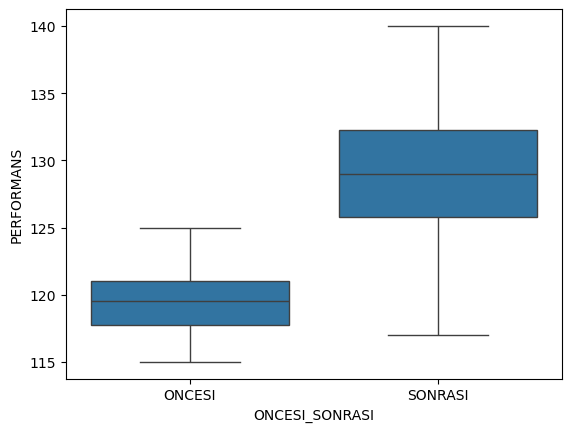

In [7]:
import seaborn as sns
sns.boxplot(x = "ONCESI_SONRASI", y = "PERFORMANS", data = BIRLIKTE)

*İstatistiki olarak değil de elimizdeki mevcut verilere bakarak eğitimin çalışan verimliliğini arttırdığı yönünde bir çıkarımda bulunabiliyoruz.Şimdilik...*

### Varsayım Kontrolleri

In [8]:
#Normallik Varsayımı
#VERİ SETİ I olarak tag'lediğimiz 'AYRIK' veri seti üzerinden varsayım kontrollerini yapacağız.

In [9]:
from scipy.stats import shapiro
shapiro(AYRIK.ONCESI)

ShapiroResult(statistic=np.float64(0.9543651286601341), pvalue=np.float64(0.10722012473424775))

In [10]:
shapiro(AYRIK.SONRASI)

ShapiroResult(statistic=np.float64(0.9780089132335147), pvalue=np.float64(0.6159508885102487))

*İki değer için de p-value değerleri alpha'dan(0.05) büyük. Yani H0'ı reddemiyoruz. Yani teorik dağılım ile normal dağılım arasında fark yoktur.*

In [11]:
#Varyans Homojenliği Varsayımı

In [12]:
import scipy.stats as stats
stats.levene(AYRIK.ONCESI, AYRIK.SONRASI)

LeveneResult(statistic=np.float64(8.31303288672351), pvalue=np.float64(0.005084451180737009))

*Varyans Homojenlik Varsayımı bize varyansların homojen olduğunu söyler. Burada p-value değerimiz kabul edilebilir hata eşik değeri olan 0.05'ten çok küçük. Yani burada H0 hipotezini reddediyoruz. Varyans homojenliği varsayımı sağlanamadı.*

*Bu durumda ne yaparız ? yapabileceğimiz iki şey var. Veri setimizi tekrar tekrar kontrol edip aykırılıkları tespit ettikten sonra veri setini tekrar varsayım testlerine tabi tutarız. İkinci yapacağımız şey ise bu varsayımı göz ardı etmek. Biz burada göz ardı edeceğiz ve iki varsayım da sağlanmış gibi bir sonraki adıma geçeceğiz.*

#### Hipotez Testi

In [13]:
from scipy.stats import ttest_rel
test_istatistigi, pvalue = ttest_rel(AYRIK["ONCESI"], AYRIK["SONRASI"])
print("Test İstatistiği : %.4f, p-value : %.4f" % (test_istatistigi, pvalue))

Test İstatistiği : -9.2815, p-value : 0.0000


*p-value değerimiz 0'a çok yakın yani alpha değerimizden(0.05) çok küçük. H0 hipotezimiz ne diyordu ? İş eğitimi öncesi çalışanların performansı ile iş eğitimi sonrası çalışanların performansı aynıdır. Bunu çürütmüş olduk. Yani şirketin çalışanları için aldığı iş eğitimi çalışanların iş verimini arttırmıştır. Bu yatırım doğru bir hamledir. Bunu bilimsel olarak kanıtlamış olduk.*